In [ ]:

# ============================================================================================
# Cell 1: Environment Initialization and Dependency Control
# ============================================================================================
!apt-get update -qq

# Florence-2 dependency.
# Reminder: Specific versions are pinned to guarantee deterministic reproducibility for the comparative study.
!pip install -q transformers==4.49.0 accelerate==0.30.1 einops==0.8.0 datasets pillow matplotlib requests

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


In [ ]:

# ============================================================================================
# Cell 2: Filesystem Integration and Hardware Resource Allocation
# ============================================================================================
import json
import os

import torch
from google.colab import drive

drive.mount('/content/drive')

# NVIDIA GPU (CUDA) utilization is mandatory for VLM inference throughput.
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"[STATUS] Hardware engine initialized: {device}")

DATASET_DIR = "/content/drive/MyDrive/Grasp Point Prediction/data/pixmo_subset_v3"

# Defensive programming
assert os.path.exists(DATASET_DIR), f"[CRITICAL] Dataset directory not found at: {DATASET_DIR}"
print(f"[STATUS] Filesystem verified. Baseline directory located.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
[STATUS] Hardware engine initialized: cuda
[STATUS] Filesystem verified. Baseline directory located.


In [ ]:

# ============================================================================================
# Cell 3: Model Instantiation and Computational Precision Configuration
# ============================================================================================
from transformers import AutoProcessor, AutoModelForCausalLM

model_id = "microsoft/Florence-2-large"
print(f"[STATUS] Initializing {model_id} with explicit FP16 precision...")

# Required to execute Florence-2's custom architecture scripts from Hugging Face.
processor = AutoProcessor.from_pretrained(model_id, trust_remote_code=True)

# Force FP16 during instantiation to ensure weight synchronization and prevent VRAM overflow.
model = AutoModelForCausalLM.from_pretrained(
    model_id,
    trust_remote_code=True,
    torch_dtype=torch.float16
).to(device).eval()

print(f"[STATUS] {model_id} successfully synchronized on {device} (FP16).")

[STATUS] Initializing microsoft/Florence-2-large with explicit FP16 precision...
[STATUS] microsoft/Florence-2-large successfully synchronized on cuda (FP16).


In [ ]:

# ============================================================================================
# Cell 4: Spatial Coordinate Logic and Deterministic Inference Orchestration
# ============================================================================================
import math
from PIL import Image

def get_box_center(box):
    """
    Translates Florence-2's bounding box output into the discrete (x, y)
    coordinate required for robotic grasp-point evaluation.
    """
    x1, y1, x2, y2 = box
    center_x = (x1 + x2) / 2
    center_y = (y1 + y2) / 2
    return (center_x, center_y)

def euclidean_distance(p1, p2):
    """
    Primary error metric for the comparative study. Quantifies grasp-point displacement.
    """
    return math.sqrt((p1[0] - p2[0])**2 + (p1[1] - p2[1])**2)

def inference(image, task_prompt, text_input=None):
    prompt = task_prompt if text_input is None else task_prompt + text_input
    inputs = processor(text=prompt, images=image, return_tensors="pt").to(device, torch.float16)

    # Force deterministic generation (beam search, no sampling) to guarantee
    # experimental reproducibility across the evaluation set.
    generated_ids = model.generate(
        input_ids=inputs["input_ids"],
        pixel_values=inputs["pixel_values"],
        max_new_tokens=1024,
        early_stopping=False,
        do_sample=False,
        num_beams=3,
    )

    generated_text = processor.batch_decode(generated_ids, skip_special_tokens=False)[0]

    # Post-process textual output into absolute pixel coordinates
    # based on the original unscaled image dimensions.
    parsed_answer = processor.post_process_generation(
        generated_text,
        task=task_prompt,
        image_size=(image.width, image.height)
    )

    return parsed_answer

print("\n✅[STATUS] Inference utilities and coordinate logic initialized.")


✅[STATUS] Inference utilities and coordinate logic initialized.


In [ ]:

# ============================================================================================
# Cell 5: Dataset Deserialization and Test Split Localization
# ============================================================================================
SPLIT_PATH = os.path.join(DATASET_DIR, "splits/test.json")

# Fail fast: Ground-truth annotations are a hard dependency for the evaluation loop.
assert os.path.exists(SPLIT_PATH), f"[CRITICAL] Target split missing. Dir contents: {os.listdir(DATASET_DIR)}"

with open(SPLIT_PATH, "r") as f:
    test_data = json.load(f)

print(f"[STATUS] Test split deserialized successfully. Total evaluation samples: {len(test_data)}")
print(f"[INFO] Data integrity check - sample target: '{test_data[0]['label']}'")

[STATUS] Test split deserialized successfully. Total evaluation samples: 183
[INFO] Data integrity check - sample target: 'apple'


In [ ]:

# ============================================================================================
# Cell 6: Automated Dual-Prompt Inference and Metric Persistence
# ============================================================================================
import pandas as pd
from tqdm import tqdm
from collections import defaultdict
import numpy as np

# Synchronize with the shared project repository via the MyDrive shortcut.
OUTPUT_DIR = "/content/drive/MyDrive/Grasp Point Prediction/evaluation/Florence2"
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"[STATUS] Shared evaluation directory synchronized: {OUTPUT_DIR}")

# Define shared prompt logic to maintain linguistic parity with the CLIP baseline.
def make_prompt_point(label):
    hints = {
        "backpack":    "Point to the strap of the backpack.",
        "bag":         "Point to the handle of the bag.",
        "calculator":  "Point to the body of the calculator.",
        "charger":     "Point to the cable of the charger.",
        "hairbrush":   "Point to the handle of the hairbrush.",
        "headphones":  "Point to the band of the headphones.",
        "highlighter": "Point to the body of the highlighter.",
        "jar":         "Point to the lid of the jar.",
        "kettle":      "Point to the handle of the kettle.",
        "keyboard":    "Point to the center of the keyboard.",
        "laptop":      "Point to the edge of the laptop.",
        "mouse":       "Point to the body of the mouse.",
        "notebook":    "Point to the spine of the notebook.",
        "onion":       "Point to the center of the onion.",
        "remote":      "Point to the body of the remote.",
        "scissor":     "Point to the handle of the scissor.",
        "stapler":     "Point to the top of the stapler.",
        "tape":        "Point to the side of the tape.",
        "toothbrush":  "Point to the handle of the toothbrush.",
        "umbrella":    "Point to the handle of the umbrella.",
        "wallet":      "Point to the body of the wallet.",
        "watch":       "Point to the strap of the watch.",
        "apple":       "Point to the center of the apple.",
        "book":        "Point to the spine of the book.",
        "bottle":      "Point to the neck of the bottle.",
        "bowl":        "Point to the rim of the bowl.",
        "cup":         "Point to the handle of the cup.",
        "fork":        "Point to the handle of the fork.",
        "keys":        "Point to the ring of the keys.",
        "knife":       "Point to the handle of the knife.",
        "marker":      "Point to the body of the marker.",
        "mug":         "Point to the handle of the mug.",
        "pen":         "Point to the body of the pen.",
        "phone":       "Point to the body of the phone.",
        "plate":       "Point to the edge of the plate.",
        "shoe":        "Point to the heel of the shoe.",
        "spoon":       "Point to the handle of the spoon.",
        "tomato":      "Point to the center of the tomato.",
        "tray":        "Point to the edge of the tray.",
        "basket":      "Point to the handle of the basket.",
        "pot":         "Point to the handle of the pot.",
        "pan":         "Point to the handle of the pan.",
        "sock":        "Point to the opening of the sock.",
        "glove":       "Point to the cuff of the glove.",
        "t-shirt":     "Point to the collar of the t-shirt.",
        "earbuds":     "Point to the body of the earbuds.",
        "egg":         "Point to the center of the egg.",
        "spatula":     "Point to the handle of the spatula.",
    }
    return hints.get(label.lower(), f"Point to the {label.lower()}.")

def make_prompt_grasp(label):
    hints = {
        "backpack":    "Grasp the strap of the backpack.",
        "bag":         "Grasp the handle of the bag.",
        "calculator":  "Grasp the body of the calculator.",
        "charger":     "Grasp the cable of the charger.",
        "hairbrush":   "Grasp the handle of the hairbrush.",
        "headphones":  "Grasp the band of the headphones.",
        "highlighter": "Grasp the body of the highlighter.",
        "jar":         "Grasp the lid of the jar.",
        "kettle":      "Grasp the handle of the kettle.",
        "keyboard":    "Grasp the center of the keyboard.",
        "laptop":      "Grasp the edge of the laptop.",
        "mouse":       "Grasp the body of the mouse.",
        "notebook":    "Grasp the spine of the notebook.",
        "onion":       "Grasp the center of the onion.",
        "remote":      "Grasp the body of the remote.",
        "scissor":     "Grasp the handle of the scissor.",
        "stapler":     "Grasp the top of the stapler.",
        "tape":        "Grasp the side of the tape.",
        "toothbrush":  "Grasp the handle of the toothbrush.",
        "umbrella":    "Grasp the handle of the umbrella.",
        "wallet":      "Grasp the body of the wallet.",
        "watch":       "Grasp the strap of the watch.",
        "apple":       "Grasp the center of the apple.",
        "book":        "Grasp the spine of the book.",
        "bottle":      "Grasp the neck of the bottle.",
        "bowl":        "Grasp the rim of the bowl.",
        "cup":         "Grasp the handle of the cup.",
        "fork":        "Grasp the handle of the fork.",
        "keys":        "Grasp the ring of the keys.",
        "knife":       "Grasp the handle of the knife.",
        "marker":      "Grasp the body of the marker.",
        "mug":         "Grasp the handle of the mug.",
        "pen":         "Grasp the body of the pen.",
        "phone":       "Grasp the body of the phone.",
        "plate":       "Grasp the edge of the plate.",
        "shoe":        "Grasp the heel of the shoe.",
        "spoon":       "Grasp the handle of the spoon.",
        "tomato":      "Grasp the center of the tomato.",
        "tray":        "Grasp the edge of the tray.",
        "basket":      "Grasp the handle of the basket.",
        "pot":         "Grasp the handle of the pot.",
        "pan":         "Grasp the handle of the pan.",
        "sock":        "Grasp the opening of the sock.",
        "glove":       "Grasp the cuff of the glove.",
        "t-shirt":     "Grasp the collar of the t-shirt.",
        "earbuds":     "Grasp the body of the earbuds.",
        "egg":         "Grasp the center of the egg.",
        "spatula":     "Grasp the handle of the spatula.",
    }
    return hints.get(label.lower(), f"Grasp the {label.lower()}.")

PROMPTS = {"point": make_prompt_point, "grasp": make_prompt_grasp}
SUCCESS_THRESHOLD = 50
results = []
category_errors = defaultdict(list)
prompt_errors = defaultdict(list)

for entry in tqdm(test_data, desc="Evaluating Florence-2"):
    image_name = os.path.basename(entry["image_path"])
    image_full_path = os.path.join(DATASET_DIR, "images", image_name)
    target_label = entry["label"]

    try:
        img = Image.open(image_full_path).convert("RGB")
        w, h = img.size
        diagonal = math.sqrt(w**2 + h**2)

        # Dataset ground truths are stored as relative percentages. Convert to absolute
        # pixel coordinates to ensure spatial parity with Florence-2 outputs.
        gt_raw = entry["points"][0]
        gt_x_px = (gt_raw['x'] / 100.0) * w
        gt_y_px = (gt_raw['y'] / 100.0) * h

        p_data = {}
        for p_name, p_fn in PROMPTS.items():
            text_prompt = p_fn(target_label)
            raw_output = inference(img, "<CAPTION_TO_PHRASE_GROUNDING>", text_input=text_prompt)
            parsed = raw_output["<CAPTION_TO_PHRASE_GROUNDING>"]

            if len(parsed["bboxes"]) > 0:
                best_box = parsed["bboxes"][0]
                pred_x, pred_y = get_box_center(best_box)
                pixel_err = euclidean_distance((pred_x, pred_y), (gt_x_px, gt_y_px))
                p_data[p_name] = {
                    "text": text_prompt, "x": pred_x, "y": pred_y,
                    "err": pixel_err, "norm_err": pixel_err / diagonal
                }

        # Compiling dual-prompt comparative metrics only for fully successful inferences.
        if "point" in p_data and "grasp" in p_data:
            p1, p2 = p_data["point"], p_data["grasp"]
            avg_err = (p1["err"] + p2["err"]) / 2.0

            # Quantify 'shift' variance for Hypothesis Testing (Prompt Sensitivity).
            shift = euclidean_distance((p1["x"], p1["y"]), (p2["x"], p2["y"]))
            consistency = round(1.0 - (shift / diagonal), 4)
            success = int(p1["err"] < SUCCESS_THRESHOLD and p2["err"] < SUCCESS_THRESHOLD)

            entry_dict = {
                "image_path": image_full_path,
                "label": target_label,
                "prompt_1": p1["text"],
                "pred_x_point": p1["x"],
                "pred_y_point": p1["y"],
                "pixel_error_point": p1["err"],
                "normalized_pixel_error_point": p1["norm_err"],
                "prompt_2": p2["text"],
                "pred_x_grasp": p2["x"],
                "pred_y_grasp": p2["y"],
                "pixel_error_grasp": p2["err"],
                "normalized_pixel_error_grasp": p2["norm_err"],
                "gt_x": gt_x_px,
                "gt_y": gt_y_px,
                "avg_pixel_error": round(avg_err, 2),
                "prompt_sensitivity": round(shift, 2),
                "prompt_consistency": consistency,
                "success_rate": success
            }
            results.append(entry_dict)
            category_errors[target_label].append(avg_err)
            prompt_errors["point"].append(p1["err"])
            prompt_errors["grasp"].append(p2["err"])

    except Exception as e:
        print(f"[RUNTIME ERROR] Instance {image_name} failed: {e}")
        continue

per_category_error = {cat: round(float(np.mean(errs)), 2) for cat, errs in category_errors.items()}
per_prompt_error = {p: round(float(np.mean(errs)), 2) for p, errs in prompt_errors.items()}

for r in results:
    r["per_category_error"] = per_category_error[r["label"]]
    r["per_prompt_error_point"] = per_prompt_error["point"]
    r["per_prompt_error_grasp"] = per_prompt_error["grasp"]

JSON_PATH = os.path.join(OUTPUT_DIR, "florence2_eval_results.json")
with open(JSON_PATH, "w") as f:
    json.dump(results, f, indent=2)

print(f"\n✅[STATUS] Inference complete. Standardized JSON Report generated at: {JSON_PATH}")

[STATUS] Shared evaluation directory synchronized: /content/drive/MyDrive/Grasp Point Prediction/evaluation/Florence2


Evaluating Florence-2: 100%|██████████| 183/183 [02:43<00:00,  1.12it/s]


✅[STATUS] Inference complete. Standardized JSON Report generated at: /content/drive/MyDrive/Grasp Point Prediction/evaluation/Florence2/florence2_eval_results.json


In [ ]:

# ============================================================================================
# Cell 7: Quantitative Performance Evaluation and Hypothesis Testing
# ============================================================================================
import os
import json
import numpy as np
from scipy import stats

errors_point = [r["pixel_error_point"] for r in results]
errors_grasp  = [r["pixel_error_grasp"]  for r in results]
sensitivity   = [r["prompt_sensitivity"] for r in results]
success       = [r["success_rate"]       for r in results]

print("\n========== EVALUATION SUMMARY ==========")
print(f"Total successful samples  : {len(results)}")

print("\n--- Pixel Error (Point Prompt) ---")
print(f"  Mean   : {np.mean(errors_point):.2f} px")
print(f"  Median : {np.median(errors_point):.2f} px")

print("\n--- Pixel Error (Grasp Prompt) ---")
print(f"  Mean   : {np.mean(errors_grasp):.2f} px")
print(f"  Median : {np.median(errors_grasp):.2f} px")

print("\n--- Prompt Sensitivity (Coordinate Shift) ---")
print(f"  Mean   : {np.mean(sensitivity):.2f} px")
print(f"  Median : {np.median(sensitivity):.2f} px")

print("\n--- Success Rate (Combined Threshold < 50px) ---")
print(f"  {np.mean(success)*100:.1f}% ({sum(success)}/{len(success)} samples)")
print("=========================================")

# A paired t-test is required to isolate the effect of the linguistic prompt
# by controlling for the inherent variance in image difficulty.
print("\n========== INFERENTIAL STATISTICS (HYPOTHESIS TESTING) ==========")
print("H0: Semantic prompt variation has no significant effect on mean pixel error.")
print("H1: Prompt phrasing significantly alters the model's spatial grounding accuracy.")

t_stat, p_value = stats.ttest_rel(errors_point, errors_grasp)

print(f"\nT-Statistic: {t_stat:.4f}")
print(f"P-Value:     {p_value:.4e}")

alpha = 0.05
if p_value < alpha:
    decision = "REJECT H0"
    conclusion = "Florence-2 exhibits statistically significant sensitivity to prompt phrasing."
    print(f"\n[DECISION] {decision} (p < {alpha})")
    print(f"CONCLUSION: {conclusion}")
else:
    decision = "FAIL TO REJECT H0"
    conclusion = "The model is robust to the semantic shift between 'point' and 'grasp' instructions."
    print(f"\n[DECISION] {decision} (p >= {alpha})")
    print(f"CONCLUSION: {conclusion}")
print("=================================================================\n")

hypothesis_data = {
    "evaluation_summary": {
        "total_successful_samples": len(results),
        "pixel_error_point": {
            "mean": round(float(np.mean(errors_point)), 2),
            "median": round(float(np.median(errors_point)), 2)
        },
        "pixel_error_grasp": {
            "mean": round(float(np.mean(errors_grasp)), 2),
            "median": round(float(np.median(errors_grasp)), 2)
        },
        "prompt_sensitivity_shift": {
            "mean": round(float(np.mean(sensitivity)), 2),
            "median": round(float(np.median(sensitivity)), 2)
        },
        "success_rate": {
            "percentage": round(float(np.mean(success) * 100), 1),
            "successful_samples": sum(success),
            "total_samples": len(success)
        }
    },
    "inferential_statistics": {
        "null_hypothesis": "Semantic prompt variation has no significant effect on mean pixel error.",
        "alternative_hypothesis": "Prompt phrasing significantly alters the model's spatial grounding accuracy.",
        "t_statistic": round(float(t_stat), 4),
        "p_value": float(p_value),
        "alpha_level": alpha,
        "decision": decision,
        "conclusion": conclusion
    }
}

HYPOTHESIS_JSON_PATH = os.path.join(OUTPUT_DIR, "hypothesis_testing.json")

with open(HYPOTHESIS_JSON_PATH, "w") as f:
    json.dump(hypothesis_data, f, indent=4)

print(f"✅[STATUS] Hypothesis testing metrics standardized and saved to: {HYPOTHESIS_JSON_PATH}")


========== EVALUATION SUMMARY ==========
Total successful samples  : 183

--- Pixel Error (Point Prompt) ---
  Mean   : 269.82 px
  Median : 127.26 px

--- Pixel Error (Grasp Prompt) ---
  Mean   : 261.71 px
  Median : 115.96 px

--- Prompt Sensitivity (Coordinate Shift) ---
  Mean   : 111.40 px
  Median : 0.97 px

--- Success Rate (Combined Threshold < 50px) ---
  22.4% (41/183 samples)

========== INFERENTIAL STATISTICS (HYPOTHESIS TESTING) ==========
H0: Semantic prompt variation has no significant effect on mean pixel error.
H1: Prompt phrasing significantly alters the model's spatial grounding accuracy.

T-Statistic: 0.4932
P-Value:     6.2244e-01

[DECISION] FAIL TO REJECT H0 (p >= 0.05)
CONCLUSION: The model is robust to the semantic shift between 'point' and 'grasp' instructions.

✅[STATUS] Hypothesis testing metrics standardized and saved to: /content/drive/MyDrive/Grasp Point Prediction/evaluation/Florence2/hypothesis_testing.json


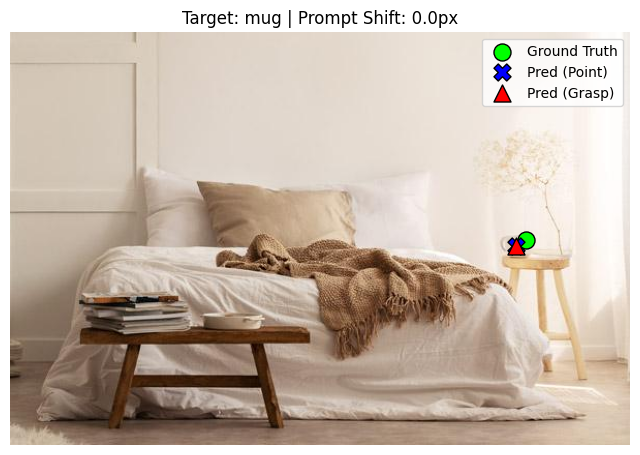

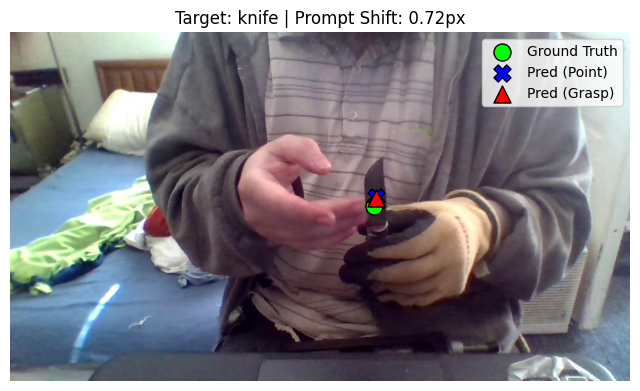

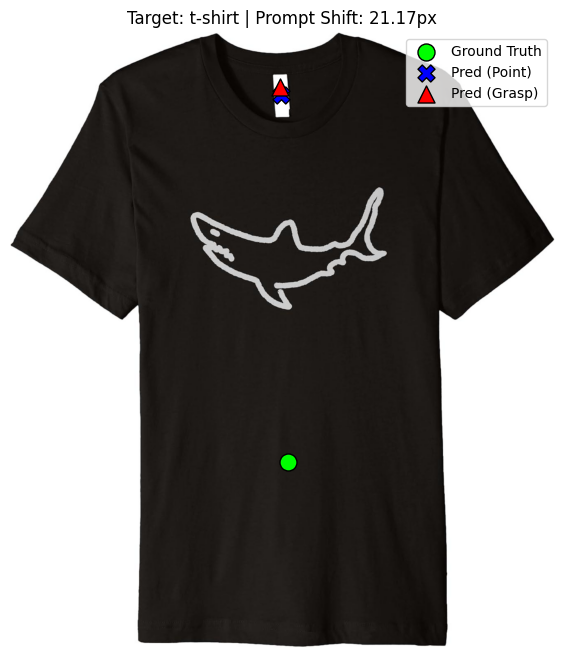

In [ ]:

# ============================================================================================
# Cell 8: Qualitative Visual Verification and Spatial Mapping
# ============================================================================================
import matplotlib.pyplot as plt
import random

# Stochastic sampling to observe if coordinate 'shifts' align with semantic
# object affordances (e.g., handles vs. centroids).
sample_size = min(3, len(results))
samples = random.sample(results, sample_size)

for row in samples:
    img = Image.open(row['image_path']).convert("RGB")

    plt.figure(figsize=(8, 8))
    plt.imshow(img)

    plt.scatter(row['gt_x'], row['gt_y'], c='lime', s=150,
                label='Ground Truth', edgecolors='black', linewidths=1, zorder=3)

    plt.scatter(row['pred_x_point'], row['pred_y_point'], c='blue', marker='X', s=150,
                edgecolors='black', linewidths=1, label='Pred (Point)', zorder=4)

    plt.scatter(row['pred_x_grasp'], row['pred_y_grasp'], c='red', marker='^', s=150,
                edgecolors='black', linewidths=1, label='Pred (Grasp)', zorder=5)

    plt.title(f"Target: {row['label']} | Prompt Shift: {row['prompt_sensitivity']}px")
    plt.legend()
    plt.axis('off')
    plt.show()

In [ ]:

# ============================================================================================
# Cell 9: Edge-Case Identification and Model Failure Characterization
# ============================================================================================
import pandas as pd

if len(results) > 0:
    df_analysis = pd.DataFrame(results)

    # Threshold exceeds the functionally acceptable radius for robotic manipulation.
    threshold_failures = df_analysis[df_analysis['success_rate'] == 0]

    print(f"[REPORT] Aggregate Threshold Failures (>50px error): {len(threshold_failures)}")

    if not threshold_failures.empty:
        # Failure distribution analysis identifies systemic class-level bottlenecks.
        print("\n[ANALYSIS] Distribution of class-specific localization failures:")
        print(threshold_failures['label'].value_counts())

        print("\n[LOG] Diagnostic review candidates (Highest Error First):")
        worst_performers = threshold_failures.sort_values(by='avg_pixel_error', ascending=False)

        for _, row in worst_performers.head(10).iterrows():
            img_name = os.path.basename(row['image_path'])
            print(f" - {img_name} ({row['label']}): Avg Error {row['avg_pixel_error']}px")
else:
    print("[CRITICAL WARNING] No successful results to analyze.")


[REPORT] Aggregate Threshold Failures (>50px error): 142

[ANALYSIS] Distribution of class-specific localization failures:
label
apple          4
backpack       4
bag            4
calculator     4
fork           4
glove          4
charger        4
tape           4
pot            4
scissor        4
spatula        4
t-shirt        4
onion          4
pan            4
keys           4
jar            4
tray           3
umbrella       3
wallet         3
toothbrush     3
spoon          3
cup            3
egg            3
headphones     3
book           3
plate          3
tomato         3
mug            3
marker         3
pen            3
knife          3
laptop         3
remote         3
stapler        2
bowl           2
earbuds        2
basket         2
phone          2
keyboard       2
kettle         2
shoe           2
sock           2
mouse          2
notebook       2
watch          2
bottle         1
hairbrush      1
highlighter    1
Name: count, dtype: int64

[LOG] Diagnostic review cand

In [ ]:

# ============================================================================================
# Cell 10: Automated Technical Reporting and Document Synthesis
# ============================================================================================
!pip install -q reportlab

import datetime
import os
import pandas as pd
from reportlab.lib import colors
from reportlab.lib.pagesizes import letter
from reportlab.lib.styles import getSampleStyleSheet
from reportlab.platypus import Paragraph, SimpleDocTemplate, Spacer, Table, TableStyle

PDF_PATH = os.path.join(OUTPUT_DIR, "Florence2_Dual_Prompt_Report.pdf")

def generate_pdf(output_path, results_list):
    if not results_list:
        print("[WARNING] No data to generate PDF.")
        return

    df = pd.DataFrame(results_list)
    doc = SimpleDocTemplate(output_path, pagesize=letter)
    styles = getSampleStyleSheet()
    elements = []

    title_style = styles['Heading1']
    title_style.alignment = 1
    elements.append(Paragraph("VLM Comparative Study: Florence-2 Prompt Sensitivity", title_style))
    elements.append(Spacer(1, 12))

    timestamp = datetime.datetime.now().strftime("%Y-%m-%d %H:%M")
    elements.append(Paragraph(f"Report Generated: {timestamp}", styles['Normal']))
    elements.append(Paragraph("Florence-2 Research Lead: Jannine G. D. MacGormain", styles['Normal']))
    elements.append(Spacer(1, 24))

    elements.append(Paragraph("Executive Summary Metrics", styles['Heading2']))

    avg_point_err = df['pixel_error_point'].mean()
    avg_grasp_err = df['pixel_error_grasp'].mean()
    avg_sensitivity = df['prompt_sensitivity'].mean()
    success_rate = df['success_rate'].mean() * 100

    summary_metrics = (
        f"<b>Mean Error ('Point' Prompt):</b> {avg_point_err:.2f} pixels<br/>"
        f"<b>Mean Error ('Grasp' Prompt):</b> {avg_grasp_err:.2f} pixels<br/>"
        f"<b>Mean Prompt Sensitivity (Coordinate Shift):</b> {avg_sensitivity:.2f} pixels<br/>"
        f"<b>Dual-Prompt Success Rate (Both <50px):</b> {success_rate:.2f}%"
    )
    elements.append(Paragraph(summary_metrics, styles['Normal']))
    elements.append(Spacer(1, 24))

    elements.append(Paragraph("Detailed Performance Log (Sample Set)", styles['Heading2']))

    table_header = [["Image", "Label", "Point Err", "Grasp Err", "Shift (px)"]]
    table_body = []

    for _, row in df.head(30).iterrows():
        img_name = os.path.basename(row['image_path'])
        table_body.append([
            img_name,
            row['label'],
            f"{row['pixel_error_point']:.1f}",
            f"{row['pixel_error_grasp']:.1f}",
            f"{row['prompt_sensitivity']:.1f}"
        ])

    report_table = Table(table_header + table_body, hAlign='LEFT')

    report_table.setStyle(TableStyle([
        ('BACKGROUND', (0, 0), (-1, 0), colors.cadetblue),
        ('TEXTCOLOR', (0, 0), (-1, 0), colors.whitesmoke),
        ('ALIGN', (0, 0), (-1, -1), 'CENTER'),
        ('FONTNAME', (0, 0), (-1, 0), 'Helvetica-Bold'),
        ('FONTSIZE', (0, 0), (-1, 0), 10),
        ('BOTTOMPADDING', (0, 0), (-1, 0), 8),
        ('GRID', (0, 0), (-1, -1), 0.5, colors.grey),
        ('ROWBACKGROUNDS', (0, 1), (-1, -1), [colors.whitesmoke, colors.lightgrey])
    ]))

    elements.append(report_table)
    doc.build(elements)

generate_pdf(PDF_PATH, results)
print(f"[STATUS] Technical PDF report synthesized successfully: {PDF_PATH}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 35.9 MB/s eta 0:00:00
[STATUS] Technical PDF report synthesized successfully: /content/drive/MyDrive/Grasp Point Prediction/evaluation/Florence2/Florence2_Dual_Prompt_Report.pdf
